First we need to load any necessary packages and the Reddit post data:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from datasets import load_dataset

In [2]:
url = "https://raw.githubusercontent.com/enoracat/Stats_507_Final_Project/main/reddit_political_subs_dataset.csv"
df = pd.read_csv(url)
    
print(df.shape)
df.head()

(7503, 23)


,Unnamed: 0,author,created_utc,domain,title,selftext,subreddit,score,num_comments,ups,...,url,subreddit_subscribers,upvote_ratio,is_original_content,media,selftext_html,author_flair_text,link_flair_text,image,image_text
0,0,FemShep_BestShep,2014-11-30 20:31:48,i.imgur.com,President Obama has achieved incredible progre...,NaN,democrats,199,58,199.0,...,https://i.imgur.com/U01V6i7.png,0.0,0.0,False,NaN,NaN,NaN,NaN,"{'bytes': None, 'path': 'https://i.imgur.com/U...",NaN
1,1,[deleted],2014-03-12 13:03:03,i.imgur.com,"As a self employed person, this is what ObamaC...",NaN,democrats,194,31,194.0,...,http://i.imgur.com/vCQdMUw.jpg,0.0,0.0,False,NaN,NaN,NaN,NaN,"{'bytes': None, 'path': 'http://i.imgur.com/vC...",NaN
2,2,Carmac,2014-11-10 15:16:55,lovebscott.com,Rolling Stone Names President Obama ‘One of th...,NaN,democrats,151,16,151.0,...,http://www.lovebscott.com/news/rolling-stone-n...,0.0,0.0,False,NaN,NaN,NaN,NaN,"{'bytes': None, 'path': 'http://www.lovebscott...",news rolling stone names president obama one s...
3,3,Albert_Flasher,2014-12-25 12:21:44,i.imgur.com,Happy Holidays!,NaN,democrats,146,22,146.0,...,http://i.imgur.com/y1lOJlS.jpg,0.0,0.0,False,NaN,NaN,NaN,NaN,"{'bytes': None, 'path': 'http://i.imgur.com/y1...",NaN
4,4,papepipo,2014-05-21 17:49:30,ofa.barackobama.com,Obama identifies 150 members of congress who d...,NaN,democrats,142,6,142.0,...,http://ofa.barackobama.com/climate-deniers/#/,0.0,0.0,False,NaN,NaN,NaN,NaN,"{'bytes': None, 'path': 'http://ofa.barackobam...",climate deniers


In [3]:
df['date'] = pd.to_datetime(df['created_utc'])

df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d %H:%M:%S')

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['hour'] = df['date'].dt.hour

In [4]:
print(df['date'].describe())
print(df['score'].describe())
print(df['num_comments'].describe())
print(df['subreddit'].value_counts())

count                             7503
mean     2018-08-24 23:53:26.072904192
min                2014-01-01 15:55:59
25%         2016-11-11 08:44:19.500000
50%                2018-11-11 14:38:54
75%         2020-10-01 20:19:03.500000
max                2022-12-30 12:02:49
Name: date, dtype: object
count      7503.000000
mean      14603.751699
std       22307.993776
min           0.000000
25%        1876.500000
50%        5404.000000
75%       17356.000000
max      214319.000000
Name: score, dtype: float64
count     7503.000000
mean      1081.797947
std       2803.804873
min          0.000000
25%        105.000000
50%        325.000000
75%        960.500000
max      90086.000000
Name: num_comments, dtype: float64
subreddit
democrats              900
socialism              900
Libertarian            900
politics               900
Conservative           900
SandersForPresident    700
LateStageCapitalism    700
The_Donald             600
JoeBiden               503
DemocraticSocialism    50

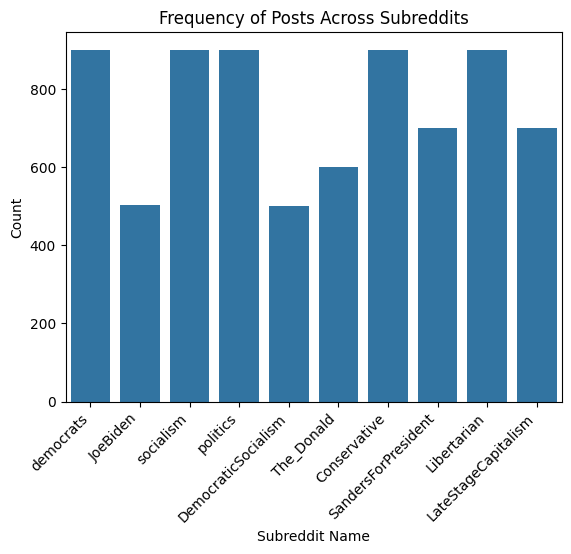

In [5]:
fig1 = sns.countplot(data=df, x = 'subreddit')
fig1.set(xlabel='Subreddit Name', ylabel = 'Count', title='Frequency of Posts Across Subreddits')
plt.xticks(rotation=45, ha='right')
plt.show()


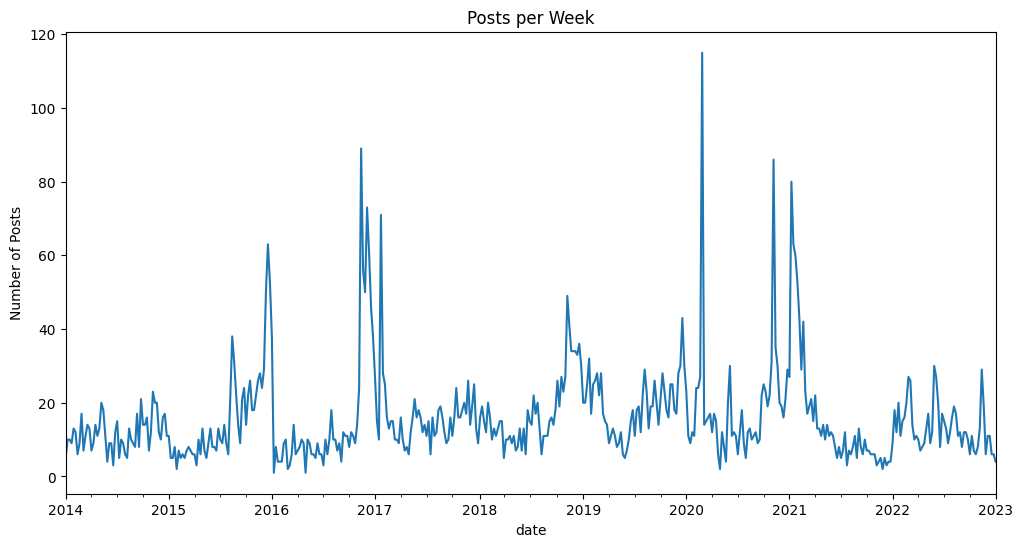

In [6]:
weekly_counts = df.set_index('date').resample('W').size()

plt.figure(figsize=(12, 6))
weekly_counts.plot()

plt.title('Posts per Week')
plt.ylabel('Number of Posts')
plt.show()

We also need to load the Jigsaw data for training the logistic regression model:

In [7]:
jigsaw = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")

train_df = jigsaw['train'].to_pandas()

summary_table = pd.DataFrame({
    'count': [train_df['toxic'].sum()],
    'proportion': [train_df['toxic'].mean()]
})

summary_table

'[WinError 10054] An existing connection was forcibly closed by the remote host' thrown while requesting HEAD https://huggingface.co/datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge/resolve/50f3c926ec8c07b440cb17b55d8cd80e8484497e/jigsaw-toxic-comment-classification-challenge.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since thesofakillers/jigsaw-toxic-comment-classification-challenge couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\enora\.cache\huggingface\datasets\thesofakillers___jigsaw-toxic-comment-classification-challenge\default\0.0.0\50f3c926ec8c07b440cb17b55d8cd80e8484497e (last modified on Tue Mar 24 20:09:29 2026).


,count,proportion
0,15294,0.095844


Creating the logistic regression model:

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

In [9]:
pipeline_logistic = Pipeline([
     ('tfidf', TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 3))),
     ('logreg', LogisticRegression(max_iter=1000, class_weight='balanced'))
 ])

In [10]:
from sklearn.model_selection import train_test_split

full_df = train_df.copy()

# final held-out evaluation set
train_pool_df, final_eval_df = train_test_split(
    full_df,
    test_size=10000,
    stratify=full_df["toxic"],
    random_state=507
)

train_pool_df = train_pool_df.reset_index(drop=True)
final_eval_df = final_eval_df.reset_index(drop=True)

# separate threshold set for BERT
train_main_df, bert_thresh_df = train_test_split(
    train_pool_df,
    test_size=10000,
    stratify=train_pool_df["toxic"],
    random_state=508
)

train_main_df = train_main_df.reset_index(drop=True)
bert_thresh_df = bert_thresh_df.reset_index(drop=True)

print("train_main_df:", train_main_df.shape)
print("bert_thresh_df:", bert_thresh_df.shape)
print("final_eval_df:", final_eval_df.shape)

train_main_df: (139571, 8)
bert_thresh_df: (10000, 8)
final_eval_df: (10000, 8)


In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=507)

In [12]:
scores = cross_val_score(
    pipeline_logistic,
    train_pool_df['comment_text'],
    train_pool_df['toxic'],
    cv=cv,
    scoring='roc_auc'   
)

print("AUC scores:", scores)
print("Mean AUC:", scores.mean())

AUC scores: [0.96326223 0.9650933  0.96415805 0.96489874 0.96209322]
Mean AUC: 0.9639011073515249


In [13]:
pipeline_logistic.fit(train_pool_df['comment_text'], train_pool_df['toxic'])


,steps,"[('tfidf', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [14]:
#pipeline_logistic.fit(train_df['comment_text'], train_df['toxic'])

feature_names = pipeline_logistic.named_steps['tfidf'].get_feature_names_out()

n_unigrams = sum(' ' not in f for f in feature_names)
n_bigrams = sum(f.count(' ') == 1 for f in feature_names)
n_trigrams = sum(f.count(' ') == 2 for f in feature_names)

print("Unigrams:", n_unigrams)
print("Bigrams:", n_bigrams)
print("Trigrams:", n_trigrams)

Unigrams: 6427
Bigrams: 2359
Trigrams: 1214


In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=507)

y_true = train_pool_df['toxic']

y_probs_cv = cross_val_predict(
    pipeline_logistic,
    train_pool_df['comment_text'],
    y_true,
    cv=cv,
    method='predict_proba'
)[:, 1]

In [16]:
thresholds = np.linspace(0.01, 0.99, 100)

f1_list = []

for t in thresholds:
    y_pred_t = (y_probs_cv >= t).astype(int)
    f1_list.append(f1_score(y_true, y_pred_t, zero_division=0))

In [17]:

best_idx = np.argmax(f1_list)
best_threshold = thresholds[best_idx]

print("Best F1 threshold:", best_threshold)
print("Best F1:", f1_list[best_idx])

Best F1 threshold: 0.7722222222222221
Best F1: 0.7576468862319372


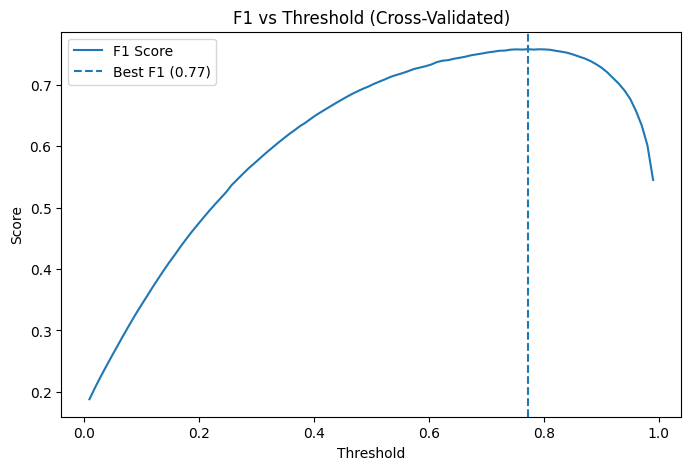

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(thresholds, f1_list, label="F1 Score")

plt.axvline(best_threshold, linestyle='--', label=f'Best F1 ({best_threshold:.2f})')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("F1 vs Threshold (Cross-Validated)")
plt.legend()

plt.show()

Now loading the Toxic BERT model directly from HuggingFace as a comparison:

In [19]:
# Load model directly
from transformers import logging
logging.set_verbosity_error()

from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
bert_pipe = pipeline("text-classification", model="unitary/toxic-bert", return_all_scores=True )

#tokenizer = AutoTokenizer.from_pretrained("unitary/toxic-bert")
#model = AutoModelForSequenceClassification.from_pretrained("unitary/toxic-bert")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Note I will only be assessing performance of the Toxic BERT model on a subset of 10,000 of the training observations to greatly reduce computational load. This still provides a solid understanding of Toxic BERT's performance on the Jugsaw data.

In [20]:
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import warnings

from transformers import logging, pipeline

use_saved_results = True

github_url = "https://raw.githubusercontent.com/enoracat/Stats_507_Final_Project/main/bert_thresh_res.pkl"

if use_saved_results == True:
    bert_thresh_res = pd.read_pickle(github_url)

else:
    logging.set_verbosity_error()
    warnings.filterwarnings("ignore")

    bert_pipe = pipeline(
        "text-classification",
        model="unitary/toxic-bert",
        top_k = None
    )

    bert_thresh_df_copy = bert_thresh_df.copy()
    bert_thresh_df_copy["text"] = bert_thresh_df_copy["comment_text"].fillna("").astype(str)

    def score_texts(texts, batch_size=8):
        results = []
        start = time.time()

        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]

            batch_results = bert_pipe(
                batch,
                batch_size=batch_size,
                truncation=True,
                max_length=512
            )

            results.extend(batch_results)

            if i % (batch_size * 20) == 0:
                print(f"Processed {i} / {len(texts)} in {time.time() - start:.1f} seconds")

        return results

    bert_thresh_df_results = score_texts(bert_thresh_df_copy["text"].tolist())

    bert_thresh_res_df = pd.DataFrame(
        [{f'bert_{item["label"]}': item["score"] for item in row} for row in bert_thresh_df_results]
    )

    bert_thresh_res = pd.concat([bert_thresh_df_copy.reset_index(drop=True), bert_thresh_res_df], axis=1)

    bert_thresh_res.to_pickle("bert_thresh_res.pkl")

In [21]:
y_eval_true = bert_thresh_res["toxic"].values
bert_probs_thresh = bert_thresh_res["bert_toxic"].values

In [22]:
thresholds = np.linspace(0.01, 0.99, 100)

f1_list = []

for t in thresholds:
    y_pred_t = (bert_probs_thresh >= t).astype(int)
    f1_list.append(f1_score(y_eval_true, y_pred_t, zero_division=0))

In [23]:

best_idx = np.argmax(f1_list)
best_threshold = thresholds[best_idx]

print("Best F1 threshold:", best_threshold)
print("Best F1:", f1_list[best_idx])

Best F1 threshold: 0.495050505050505
Best F1: 0.9245867768595041


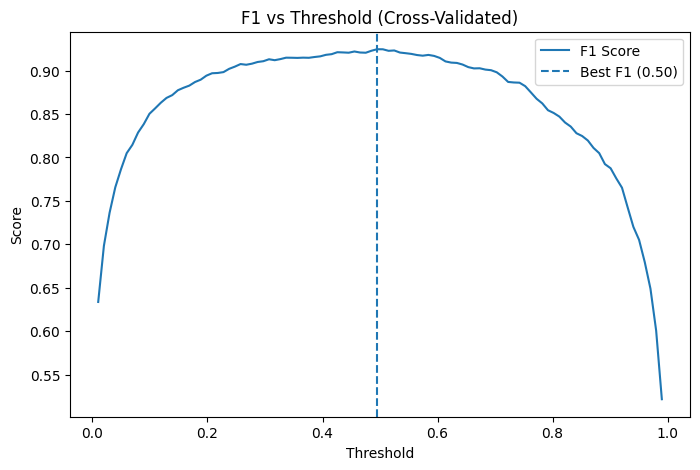

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(thresholds, f1_list, label="F1 Score")

plt.axvline(best_threshold, linestyle='--', label=f'Best F1 ({best_threshold:.2f})')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("F1 vs Threshold (Cross-Validated)")
plt.legend()

plt.show()

In [25]:
import time
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import warnings

from transformers import logging, pipeline

use_saved_results = True

github_url = "https://raw.githubusercontent.com/enoracat/Stats_507_Final_Project/main/bert_eval_scores.pkl"

if use_saved_results == True:
    bert_eval = pd.read_pickle(github_url)

else:
    logging.set_verbosity_error()
    warnings.filterwarnings("ignore")

    bert_pipe = pipeline(
        "text-classification",
        model="unitary/toxic-bert",
        top_k = None
    )

    final_eval_df_copy = final_eval_df.copy()
    final_eval_df_copy["text"] = final_eval_df_copy["comment_text"].fillna("").astype(str)

    def score_texts(texts, batch_size=8):
        results = []
        start = time.time()

        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]

            batch_results = bert_pipe(
                batch,
                batch_size=batch_size,
                truncation=True,
                max_length=512
            )

            results.extend(batch_results)

            if i % (batch_size * 20) == 0:
                print(f"Processed {i} / {len(texts)} in {time.time() - start:.1f} seconds")

        return results

    bert_eval_results = score_texts(final_eval_df_copy["text"].tolist())

    bert_score_df = pd.DataFrame(
        [{f'bert_{item["label"]}': item["score"] for item in row} for row in bert_eval_results]
    )

    bert_eval = pd.concat([final_eval_df_copy.reset_index(drop=True), bert_score_df], axis=1)

    bert_eval.to_pickle("bert_eval_scores.pkl")

In [26]:
y_eval = bert_eval["toxic"].values
bert_probs = bert_eval["bert_toxic"].values
bert_pred = (bert_probs >= 0.495).astype(int)

In [27]:
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

In [28]:
print("Toxic-BERT on evaluation subset")
print("ROC-AUC:", roc_auc_score(y_eval, bert_probs))
print("Precision:", precision_score(y_eval, bert_pred))
print("Recall:", recall_score(y_eval, bert_pred))
print("F1:", f1_score(y_eval, bert_pred))
print(confusion_matrix(y_eval, bert_pred))

Toxic-BERT on evaluation subset
ROC-AUC: 0.9976150499709313
Precision: 0.9190871369294605
Recall: 0.9248434237995825
F1: 0.9219562955254943
[[8964   78]
 [  72  886]]


While I already did fit analysis on the logistic regression with the full Jigsaw training dataset, I will also perform fit analysis for the random subset of 10,000 observations to allow for direct comparison in performance of the logistic regression and Toxic BERT:

In [29]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

X_eval = final_eval_df["comment_text"].fillna("").astype(str)
y_eval = final_eval_df["toxic"].values

logreg_probs = pipeline_logistic.predict_proba(X_eval)[:, 1]
logreg_pred = (logreg_probs >= .77).astype(int)

print("Logistic Regression on evaluation subset")
print("ROC-AUC:", roc_auc_score(y_eval, logreg_probs))
print("Precision:", precision_score(y_eval, logreg_pred))
print("Recall:", recall_score(y_eval, logreg_pred))
print("F1:", f1_score(y_eval, logreg_pred))
print(confusion_matrix(y_eval, logreg_pred))

Logistic Regression on evaluation subset
ROC-AUC: 0.965153743213646
Precision: 0.8128654970760234
Recall: 0.7254697286012526
F1: 0.7666850523993382
[[8882  160]
 [ 263  695]]


In [30]:
results_compare = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "ROC_AUC": roc_auc_score(y_eval, logreg_probs),
        "Precision": precision_score(y_eval, logreg_pred),
        "Recall": recall_score(y_eval, logreg_pred),
        "F1": f1_score(y_eval, logreg_pred)
    },
    {
        "Model": "Toxic-BERT",
        "ROC_AUC": roc_auc_score(y_eval, bert_probs),
        "Precision": precision_score(y_eval, bert_pred),
        "Recall": recall_score(y_eval, bert_pred),
        "F1": f1_score(y_eval, bert_pred)
    }
])

results_compare

,Model,ROC_AUC,Precision,Recall,F1
0,Logistic Regression,0.965154,0.812865,0.725470,0.766685
1,Toxic-BERT,0.997615,0.919087,0.924843,0.921956


In [31]:
eval_compare = pd.DataFrame({
    "true": y_eval,
    "logreg_prob": logreg_probs,
    "logreg_pred": logreg_pred,
    "bert_prob": bert_probs,
    "bert_pred": bert_pred
})

(eval_compare["logreg_pred"] != eval_compare["bert_pred"]).mean()

np.float64(0.0395)

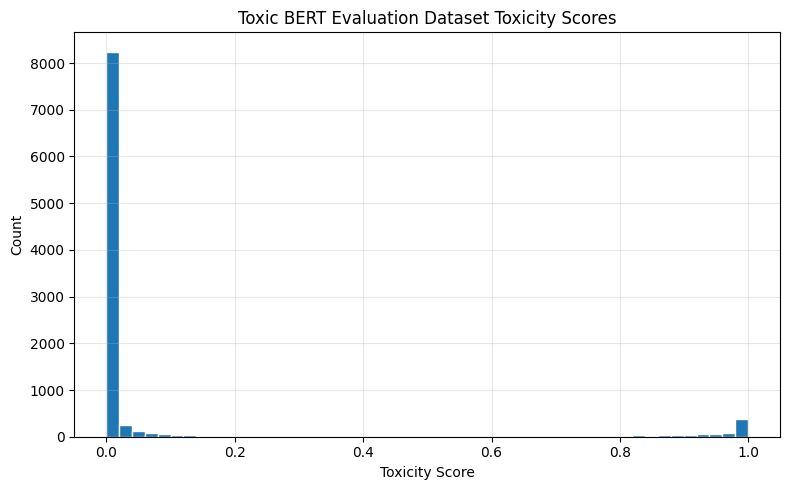

In [32]:
plt.figure(figsize=(8,5))
plt.hist(eval_compare["bert_prob"], bins=50, edgecolor="white")
plt.xlabel("Toxicity Score")
plt.ylabel("Count")
plt.title("Toxic BERT Evaluation Dataset Toxicity Scores")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
eval_compare["bert_prob"].describe()

count    10000.000000
mean         0.096809
std          0.266471
min          0.000492
25%          0.000612
50%          0.000762
75%          0.004167
max          0.999219
Name: bert_prob, dtype: float64

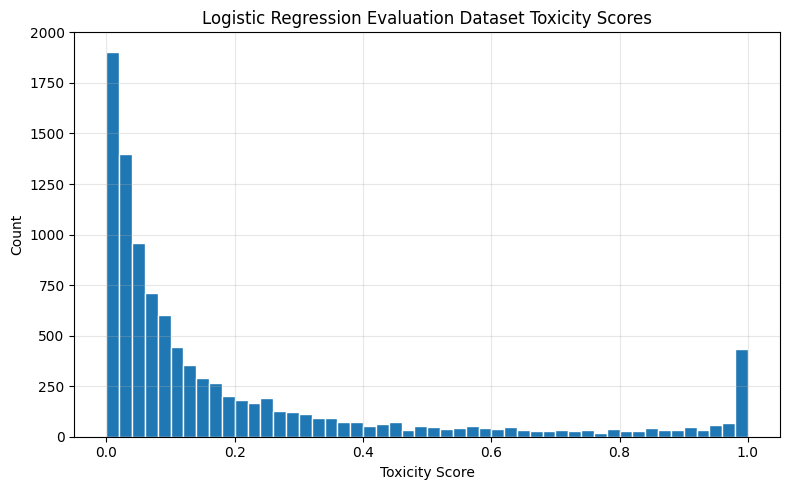

In [34]:
plt.figure(figsize=(8,5))
plt.hist(eval_compare["logreg_prob"], bins=50, edgecolor="white")
plt.xlabel("Toxicity Score")
plt.ylabel("Count")
plt.title("Logistic Regression Evaluation Dataset Toxicity Scores")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
eval_compare["logreg_prob"].describe()

count    10000.000000
mean         0.202868
std          0.275241
min          0.000119
25%          0.027553
50%          0.081219
75%          0.243508
max          1.000000
Name: logreg_prob, dtype: float64

Now loading the Reddit data and getting Toxicity scores from Toxic BERT:

In [36]:
import time
from tqdm.auto import tqdm
import warnings

use_github_results = True

github_url = "https://raw.githubusercontent.com/enoracat/Stats_507_Final_Project/main/bert_toxicity_df.pkl"

if use_github_results == True:
    bert_reddit = pd.read_pickle(github_url)
    
else:
    logging.set_verbosity_error()
    warnings.filterwarnings("ignore")

    bert_pipe = pipeline(
        "text-classification",
        model="unitary/toxic-bert",
        top_k = None
    )

    df = df.copy()
    df["text"] = df["title"].fillna("").astype(str)

    def score_texts(texts, batch_size=8):
        results = []
        start = time.time()

        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]
            batch_results = bert_pipe(batch, batch_size=batch_size, truncation=True, max_length=512)
            results.extend(batch_results)

            if i % (batch_size * 20) == 0:
                print(f"Processed {i} / {len(texts)} in {time.time() - start:.1f} seconds")

        return results

    reddit_bert_toxicity = score_texts(df["text"].tolist())

    bert_score_df = pd.DataFrame(
        [{item["label"]: item["score"] for item in row} for row in reddit_bert_toxicity]
    )


    bert_toxicity_df = pd.concat([df.reset_index(drop=True), bert_score_df], axis=1)
    
    bert_toxicity_df.to_pickle("bert_toxicity_df.pkl")

    bert_reddit = bert_toxicity_df

In [37]:
bert_reddit['toxic'].describe()

count    7503.000000
mean        0.060635
std         0.184591
min         0.000528
25%         0.000831
50%         0.001524
75%         0.011508
max         0.998947
Name: toxic, dtype: float64

In [38]:
(bert_reddit["toxic"] >= 0.495).mean()

np.float64(0.04958016793282687)

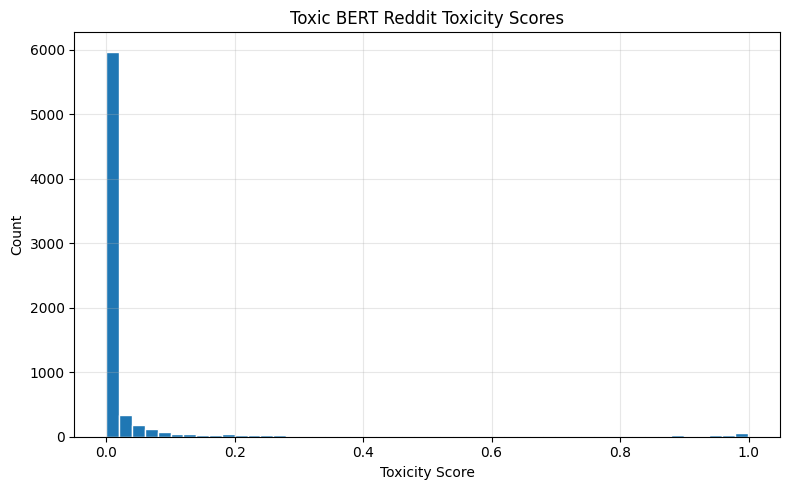

In [39]:
bert_scores = bert_reddit["toxic"]

plt.figure(figsize=(8,5))
plt.hist(bert_scores, bins=50, edgecolor="white")
plt.xlabel("Toxicity Score")
plt.ylabel("Count")
plt.title("Toxic BERT Reddit Toxicity Scores")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Now that we have both models, we need to evaluate how they differ in toxicity ratings on the Reddit dataset:

In [40]:
titles = df['title'].fillna('').astype(str)
probs = pipeline_logistic.predict_proba(titles)[:, 1]
df['logreg_prob'] = probs
df['logreg_pred'] = (probs >= 0.77).astype(int)

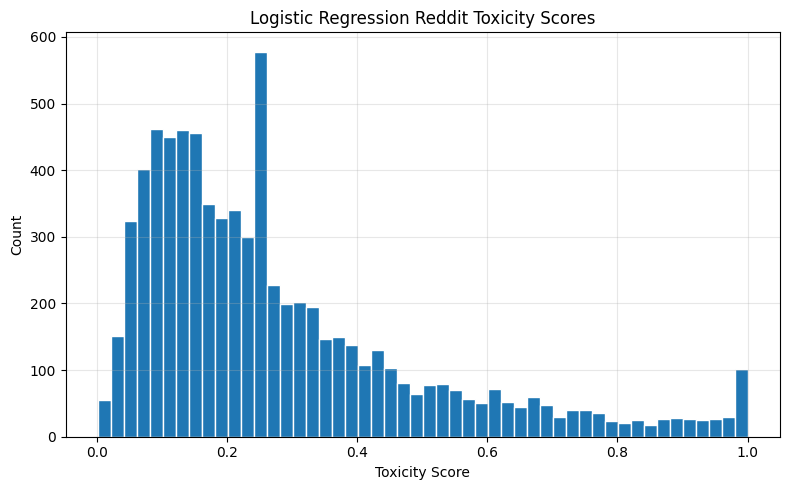

In [41]:
scores = df['logreg_prob']

plt.figure(figsize=(8,5))
plt.hist(scores, bins=50, edgecolor="white")
plt.xlabel("Toxicity Score")
plt.ylabel("Count")
plt.title("Logistic Regression Reddit Toxicity Scores")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
df['logreg_pred_oldthresh'] = (probs >= 0.5).astype(int)

n_toxic_logreg_oldthresh = df['logreg_pred_oldthresh'].sum()
prop_toxic_logreg_oldthresh = df['logreg_pred_oldthresh'].mean()

print("Logistic regression")
print("Number labeled toxic:", n_toxic_logreg_oldthresh)
print("Proportion labeled toxic:", prop_toxic_logreg_oldthresh)


Logistic regression
Number labeled toxic: 1107
Proportion labeled toxic: 0.14754098360655737


In [43]:
n_toxic_logreg = df['logreg_pred'].sum()
prop_toxic_logreg = df['logreg_pred'].mean()

print("Logistic regression")
print("Number labeled toxic:", n_toxic_logreg)
print("Proportion labeled toxic:", prop_toxic_logreg)

Logistic regression
Number labeled toxic: 367
Proportion labeled toxic: 0.04891376782620285


In [44]:
df['bert_prob'] = bert_reddit['toxic']
df['bert_pred'] = (bert_reddit['toxic'] >= 0.495).astype(int)

n_toxic_bert = df['bert_pred'].sum()
prop_toxic_bert = df['bert_pred'].mean()

print("ToxicBERT")
print("Number labeled toxic:", n_toxic_bert)
print("Proportion labeled toxic:", prop_toxic_bert)

ToxicBERT
Number labeled toxic: 372
Proportion labeled toxic: 0.04958016793282687


In [45]:
(df['logreg_pred'] != df['bert_pred']).mean()

np.float64(0.04118352658936426)

In [46]:
pd.crosstab(
    df['logreg_pred'],
    df['bert_pred'],
    rownames=['LogReg'],
    colnames=['BERT']
)

BERT,0,1
LogReg,,
0,6979,157
1,152,215


In [47]:
pd.set_option('display.max_colwidth', None)
df.loc[df['logreg_pred'] != df['bert_pred'], ['title', 'logreg_prob', 'bert_prob']].head(30)

,title,logreg_prob,bert_prob
7,Memo to Dick Cheney: George Washington ordered execution as penalty for torturing prisoners,0.915927,0.030690
27,"Jon Stewart on Fox's 'Latte Salute' Coverage: ""F**k You All &amp; Your False Patriotism""",0.360641,0.959717
30,Republicans Finally Admit There's No Benghazi Scandal,0.789392,0.011497
50,"Yes, Dick Cheney is lying when he claims that Obama dropped Bush’s missile defense plan after a ‘mere request’ from Putin",0.792446,0.036982
53,Bill Nye tells Bill Maher: America can’t afford a generation of ‘scientifically illiterate’ children,0.166011,0.573710
62,"Christie Says, ""I Am Not a Bully."" Here Are 8 Videos of Him Yelling, Name-Calling, and Belittling People. - ""Something may be going down, but it ain't going to be jobs sweetheart.""",0.775930,0.014459
70,"Nevada rancher is just a welfare cowboy: ""He’s no hero. He’s a deadbeat. A moocher, flouting laws and bilking the taxpayer while law-abiding citizens pay their bills""",0.186553,0.631563
102,"Yes, The Planned Parenthood Shooter Is A ‘Christian Terrorist’",0.272198,0.587295
142,"Bernie Sanders is officially running. We complain about how awful Republicans are, we complain that Democrats just aren't doing enough. This page says enough.",0.785227,0.159656
146,John Oliver rips America’s disgraceful maternity leave policy: Thanks for giving us life — “now get the f*ck back to work” - The U.S. is 1 of only 2 countries in the world that doesn't offer paid time off to new mothers,0.595004,0.887475


In [48]:
#also looking at cases where the models AGREED

In [49]:
pd.set_option('display.max_colwidth', None)
df.loc[
    (df['logreg_pred'] == df['bert_pred']) & (df['logreg_pred'] == 1),
    ['title', 'logreg_prob', 'bert_prob']
].head(30)

,title,logreg_prob,bert_prob
49,It Only Takes 175 Words for this Canadian to Lay an Epic Smackdown on Idiot Americans Who Rejected Obama for the GOP,0.942813,0.829787
220,If You Still Vote For Trump After He Implied Obama Was In On The Orlando Shooting: Fuck You.,0.982709,0.987659
268,"White nationalists target Jews in small Montana town - A call to action in the Daily Stormer describes Jews as a “vicious, evil race of hate-filled psychopaths.”",0.865641,0.849525
316,"Remember when people like Sarah Palin shit their pants when Obama traveled on the taxpayer's dime? Trump is about to ""bankrupt"" the U.S. Secret Service. Where are those complaints now?",0.901934,0.852648
410,"Stephen King on Twitter: ""Fuck your wall. Split that 5 billion between at-risk children who don’t have lunches and vets who can’t get proper medical and psychological treatment. Fuck your vanity project. Do something good for once.""",0.994080,0.997945
427,Gen Z here voting in the midterm because fuck the GOP,0.999880,0.992155
465,Only Caravan is the Republican One of Fools.,0.823402,0.785844
523,How long before Trump supporters realize that you don’t surround yourself with dirty guys unless you’re dirty yourself? -Stephen King,0.902133,0.582454
533,Being this stupid should be a crime...,0.999213,0.951331
599,"Kurt Eichenwald: ""I have to get this off my chest. A cheating sleaze who grifts his way through life attacks a deceased great American, John McCain. The grifter’s cult then attacks McCain family, including widow @cindymccain and daughter @MeghanMcCain. Trump is a pig. And his fans are evil.""",0.848088,0.897336


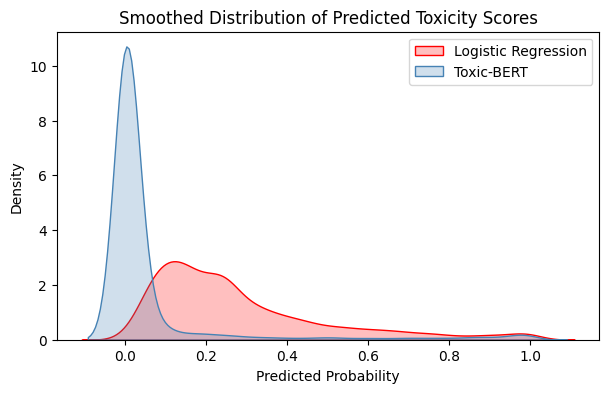

In [50]:
plt.figure(figsize=(7, 4))

sns.kdeplot(df["logreg_prob"], label="Logistic Regression", fill=True, color = "r")
sns.kdeplot(df["bert_prob"], label="Toxic-BERT", fill=True, color = "steelblue")

plt.xlabel("Predicted Probability")
plt.title("Smoothed Distribution of Predicted Toxicity Scores")
plt.legend()
plt.show()

After looking at overall disagreement, we can also consider if disagreement differs based on covariates such as post length, subreddit, and ....:

In [51]:
df['char_length'] = df['title'].str.len()
df['word_count'] = df['title'].str.split().str.len()

df['prob_diff'] = df['bert_prob'] - df['logreg_prob']

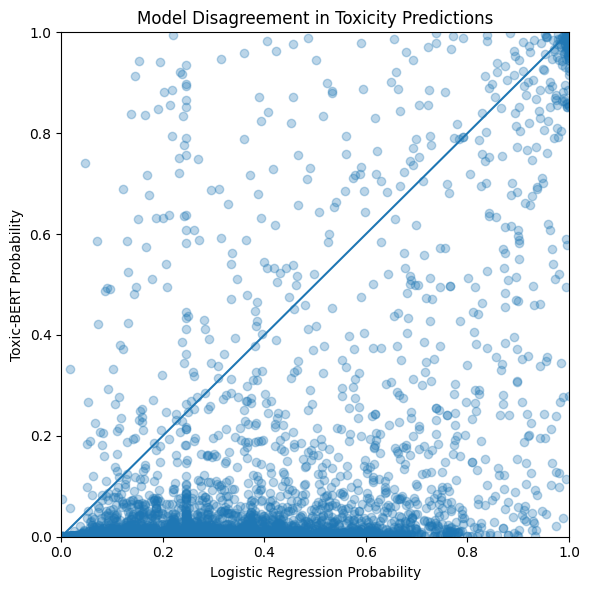

In [69]:
plt.figure(figsize=(6, 6))

plt.scatter(
    df["logreg_prob"],
    df["bert_prob"],
    alpha=0.3
)

# diagonal line (perfect agreement)
plt.plot([0, 1], [0, 1])

plt.xlabel("Logistic Regression Probability")
plt.ylabel("Toxic-BERT Probability")
plt.title("Model Disagreement in Toxicity Predictions")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

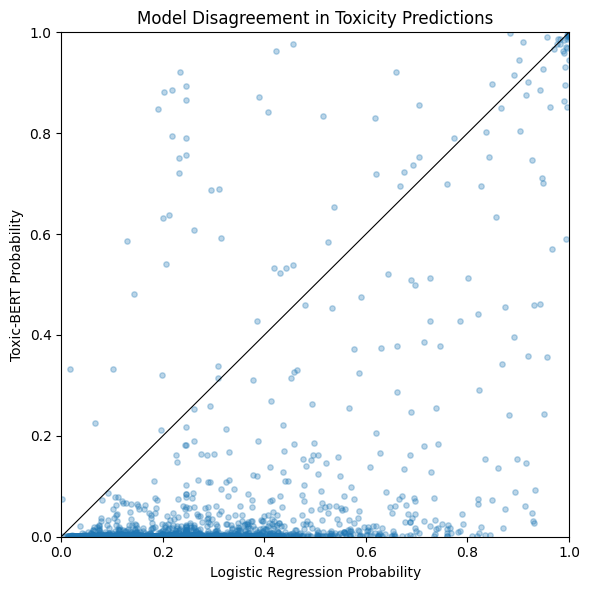

In [79]:
df_sample = df.sample(n=2000, random_state=1)

plt.figure(figsize=(6, 6))

plt.scatter(
    df_sample["logreg_prob"],
    df_sample["bert_prob"],
    alpha=0.3,
    s = 15
)

# diagonal line (perfect agreement)
plt.plot([0, 1], [0, 1], linewidth = 0.8, color = "black")

plt.xlabel("Logistic Regression Probability")
plt.ylabel("Toxic-BERT Probability")
plt.title("Model Disagreement in Toxicity Predictions")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

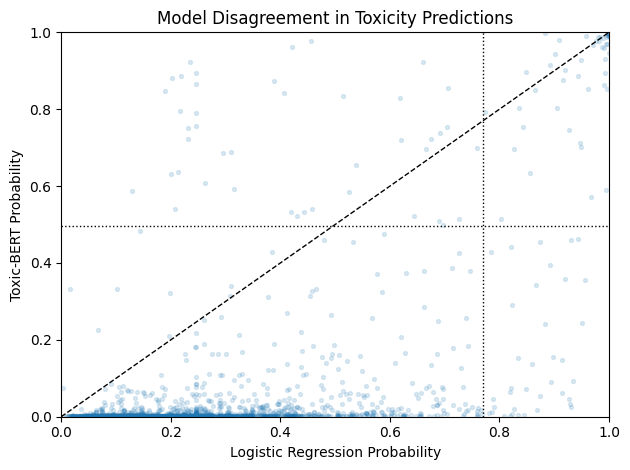

In [80]:
plt.scatter(
    df_sample["logreg_prob"],
    df_sample["bert_prob"],
    alpha=0.15,
    s=8
)

# agreement line
plt.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)

# thresholds
plt.axvline(0.77, color="black", linestyle=":", linewidth=1)
plt.axhline(0.495, color="black", linestyle=":", linewidth=1)

plt.xlabel("Logistic Regression Probability")
plt.ylabel("Toxic-BERT Probability")
plt.title("Model Disagreement in Toxicity Predictions")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

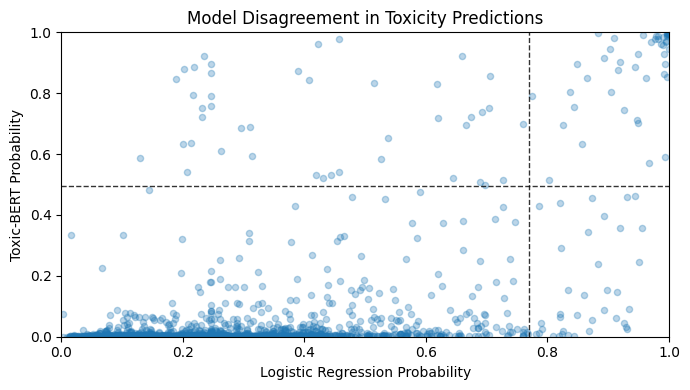

In [98]:
plt.figure(figsize=(7, 4))


plt.scatter(
    df_sample["logreg_prob"],
    df_sample["bert_prob"],
    alpha=0.3,
    s = 20
)


# thresholds
plt.axvline(0.77, color="black", linestyle="--", linewidth=1, alpha = 0.8)
plt.axhline(0.495, color="blacK", linestyle="--", linewidth=1, alpha = 0.8)

plt.xlabel("Logistic Regression Probability")
plt.ylabel("Toxic-BERT Probability")
plt.title("Model Disagreement in Toxicity Predictions")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.tight_layout()
plt.savefig('score_disagree.png', dpi=300, bbox_inches='tight')
plt.show()

In [52]:
df['disagree'] = (df['logreg_pred'] != df['bert_pred']).astype(int)

In [53]:
subreddit_summary = df.groupby('subreddit').agg(
    n_posts=('title', 'size'),
    logreg_toxic_rate=('logreg_pred', 'mean'),
    bert_toxic_rate=('bert_pred', 'mean'),
    logreg_mean_score=('logreg_prob', 'mean'),
    bert_mean_score=('bert_prob', 'mean'),
    disagreement_rate=('disagree', 'mean') 
).reset_index().sort_values('disagreement_rate', ascending=False)

In [54]:
df['disagree_dir'] = 0

df.loc[(df['logreg_pred'] == 1) & (df['bert_pred'] == 0), 'disagree_dir'] = 1
df.loc[(df['logreg_pred'] == 0) & (df['bert_pred'] == 1), 'disagree_dir'] = -1

In [55]:
subreddit_direction = df.groupby('subreddit').agg(
    mean_direction=('disagree_dir', 'mean'),
    n_posts=('title', 'size')
).reset_index()

In [56]:
df['lr_only'] = ((df['logreg_pred'] == 1) & (df['bert_pred'] == 0)).astype(int)
df['bert_only'] = ((df['bert_pred'] == 1) & (df['logreg_pred'] == 0)).astype(int)

subreddit_dir = df.groupby('subreddit').agg(
    lr_only_rate=('lr_only', 'mean'),
    bert_only_rate=('bert_only', 'mean')
).reset_index()

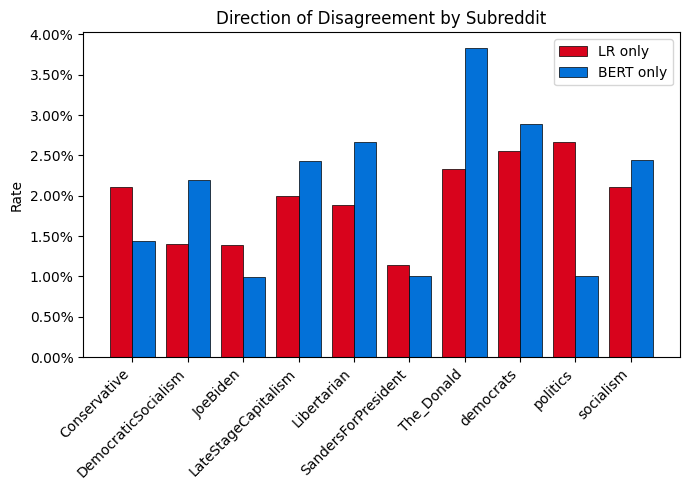

In [57]:
import numpy as np
import matplotlib.ticker as mtick

subs = subreddit_dir['subreddit']
x = np.arange(len(subs))

plt.figure(figsize=(7, 5))
plt.bar(x - 0.2, subreddit_dir['lr_only_rate'], width=0.4, label='LR only', color = '#d8031c', edgecolor='black', linewidth=0.5)
plt.bar(x + 0.2, subreddit_dir['bert_only_rate'], width=0.4, label='BERT only', color = '#0371d8', edgecolor='black', linewidth=0.5)

plt.xticks(x, subs, rotation=45, ha='right')
plt.ylabel('Rate')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Direction of Disagreement by Subreddit')
plt.legend()
plt.tight_layout()
plt.show()


In [58]:
subreddit_toxic = df.groupby('subreddit').agg(
    logreg_toxic_rate=('logreg_pred', 'mean'),
    bert_toxic_rate=('bert_pred', 'mean'),
    n_posts=('title', 'size')
).reset_index()

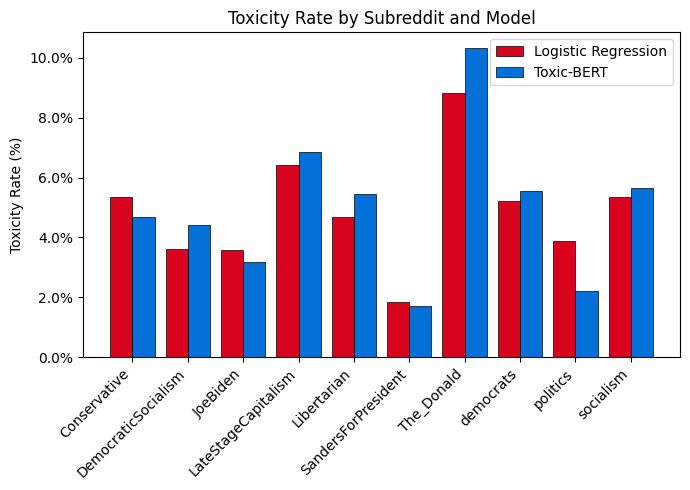

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

subs = subreddit_toxic['subreddit']
x = np.arange(len(subs))

plt.figure(figsize=(7, 5))

plt.bar(x - 0.2, subreddit_toxic['logreg_toxic_rate'], width=0.4,
        label='Logistic Regression', color='#d8031c', edgecolor='black', linewidth=0.5)

plt.bar(x + 0.2, subreddit_toxic['bert_toxic_rate'], width=0.4,
        label='Toxic-BERT', color='#0371d8', edgecolor='black', linewidth=0.5)

plt.xticks(x, subs, rotation=45, ha='right')
plt.ylabel('Toxicity Rate (%)')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Toxicity Rate by Subreddit and Model')
plt.legend()

plt.tight_layout()
plt.savefig('subreddit_toxic.png', dpi=300, bbox_inches='tight')
plt.show()

In [60]:
df['lr_only'] = ((df['logreg_pred'] == 1) & (df['bert_pred'] == 0)).astype(int)
df['bert_only'] = ((df['bert_pred'] == 1) & (df['logreg_pred'] == 0)).astype(int)

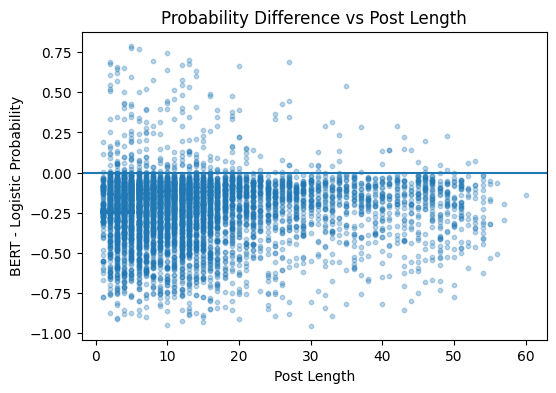

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df['word_count'], df['prob_diff'], alpha=0.3, s=10)
plt.xlabel('Post Length')
plt.ylabel('BERT - Logistic Probability')
plt.title('Probability Difference vs Post Length')
plt.axhline(0)
plt.show()

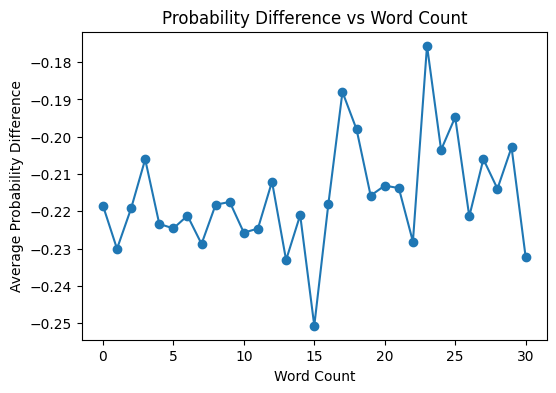

In [62]:
df['length_bin'] = pd.qcut(df['word_count'], 60, duplicates='drop')

score_summary = df.groupby('length_bin', observed=True)['prob_diff'].mean()

plt.figure(figsize=(6,4))
plt.plot(range(len(score_summary)), score_summary.values, marker='o')
plt.xlabel('Word Count')
plt.ylabel('Average Probability Difference')
plt.title('Probability Difference vs Word Count')
plt.show()

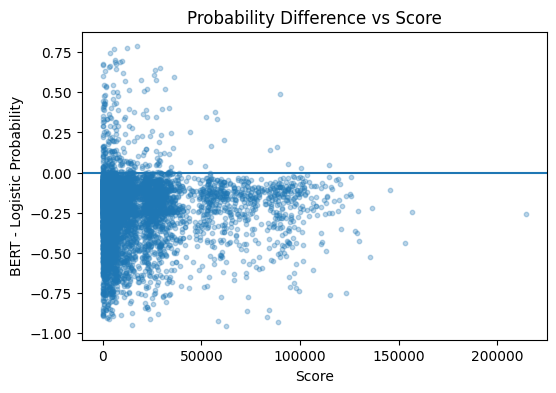

In [63]:
plt.figure(figsize=(6,4))
plt.scatter(df['score'], df['prob_diff'], alpha=0.3, s=10)
plt.xlabel('Score')
plt.ylabel('BERT - Logistic Probability')
plt.title('Probability Difference vs Score')
plt.axhline(0)
plt.show()

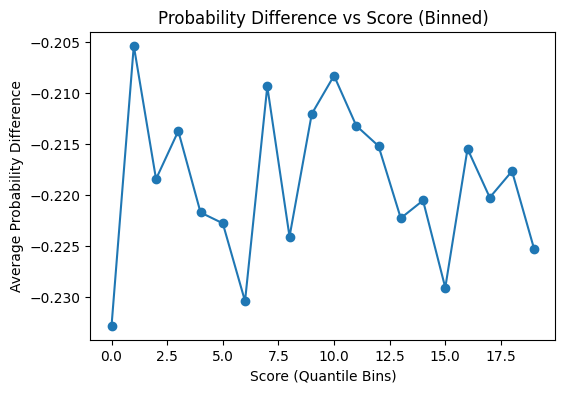

In [64]:
df['score_bin'] = pd.qcut(df['score'], 20, duplicates='drop')

score_summary = df.groupby('score_bin', observed=True)['prob_diff'].mean()

plt.figure(figsize=(6,4))
plt.plot(range(len(score_summary)), score_summary.values, marker='o')
plt.xlabel('Score (Quantile Bins)')
plt.ylabel('Average Probability Difference')
plt.title('Probability Difference vs Score (Binned)')
plt.show()

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick



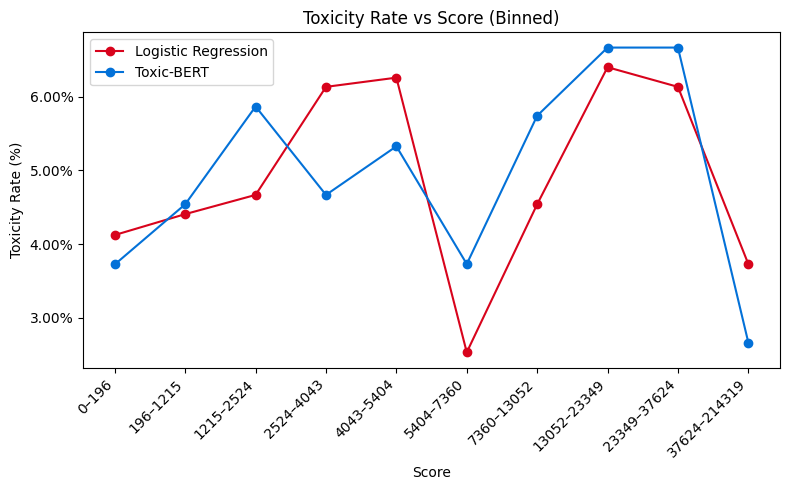

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Create bins
df['score_bin'] = pd.qcut(df['score'], q=10, duplicates='drop')

# Aggregate
score_plot = df.groupby('score_bin', observed=False).agg(
    logreg_toxic_rate=('logreg_pred', 'mean'),
    bert_toxic_rate=('bert_pred', 'mean')
).reset_index()

# Convert intervals to readable strings
score_plot['bin_label'] = score_plot['score_bin'].apply(
    lambda x: f"{int(x.left)}–{int(x.right)}"
)

# Plot
plt.figure(figsize=(8,5))

plt.plot(score_plot['bin_label'], score_plot['logreg_toxic_rate'],
         marker='o', label='Logistic Regression', color='#d8031c')

plt.plot(score_plot['bin_label'], score_plot['bert_toxic_rate'],
         marker='o', label='Toxic-BERT', color='#0371d8')

plt.xticks(rotation=45, ha='right')
plt.ylabel('Toxicity Rate (%)')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xlabel('Score')
plt.title('Toxicity Rate vs Score (Binned)')
plt.legend()

plt.tight_layout()
plt.show()

In [101]:
df['score'].describe()

count      7503.000000
mean      14603.751699
std       22307.993776
min           0.000000
25%        1876.500000
50%        5404.000000
75%       17356.000000
max      214319.000000
Name: score, dtype: float64

In [102]:
df_lr_only = df[(df['logreg_pred'] == 1) & (df['bert_pred'] == 0)]
df_bert_only = df[(df['bert_pred'] == 1) & (df['logreg_pred'] == 0)]

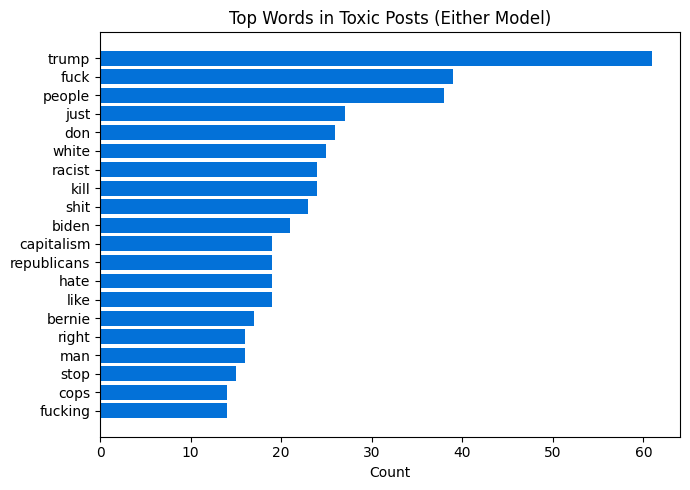

In [103]:
# Posts classified as toxic by either model
df_any_toxic = df[(df['logreg_pred'] == 1) | (df['bert_pred'] == 1)]

texts = df_any_toxic['title'].fillna('').astype(str)

# Vectorize
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(texts)
word_counts = X.sum(axis=0).A1
words = vectorizer.get_feature_names_out()

freq_df = pd.DataFrame({'word': words, 'count': word_counts})
freq_df = freq_df.sort_values('count', ascending=False)

# Plot
plt.figure(figsize=(7,5))
plt.barh(freq_df['word'], freq_df['count'], color='#0371d8')
plt.gca().invert_yaxis()
plt.title('Top Words in Toxic Posts (Either Model)')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

In [104]:
df_lr_toxic = df[df['logreg_pred'] == 1]
df_bert_toxic = df[df['bert_pred'] == 1]

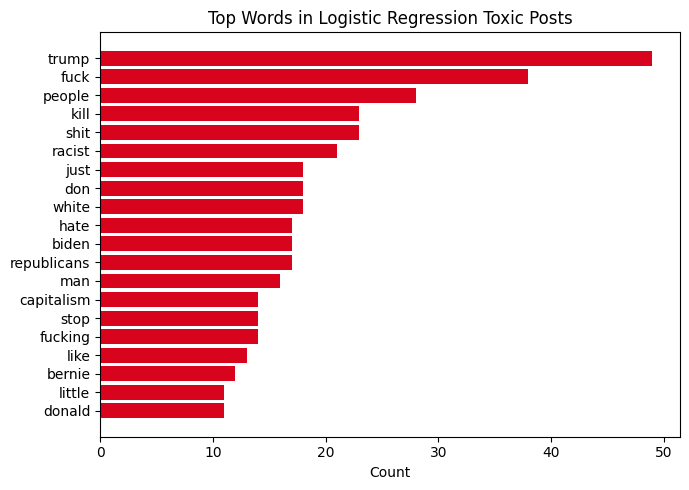

In [105]:
texts_lr = df_lr_toxic['title'].fillna('').astype(str)

vectorizer_lr = CountVectorizer(
    stop_words='english',
    max_features=20
)

X_lr = vectorizer_lr.fit_transform(texts_lr)
counts_lr = X_lr.sum(axis=0).A1
words_lr = vectorizer_lr.get_feature_names_out()

freq_lr = pd.DataFrame({'word': words_lr, 'count': counts_lr})
freq_lr = freq_lr.sort_values('count', ascending=False)

plt.figure(figsize=(7,5))
plt.barh(freq_lr['word'], freq_lr['count'], color='#d8031c')
plt.gca().invert_yaxis()
plt.title('Top Words in Logistic Regression Toxic Posts')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

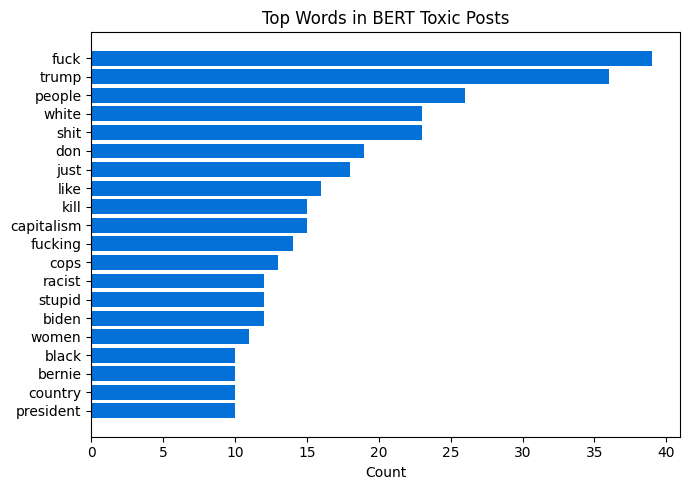

In [106]:
texts_bert = df_bert_toxic['title'].fillna('').astype(str)

vectorizer_bert = CountVectorizer(
    stop_words='english',
    max_features=20
)

X_bert = vectorizer_bert.fit_transform(texts_bert)
counts_bert = X_bert.sum(axis=0).A1
words_bert = vectorizer_bert.get_feature_names_out()

freq_bert = pd.DataFrame({'word': words_bert, 'count': counts_bert})
freq_bert = freq_bert.sort_values('count', ascending=False)

plt.figure(figsize=(7,5))
plt.barh(freq_bert['word'], freq_bert['count'], color='#0371d8')
plt.gca().invert_yaxis()
plt.title('Top Words in BERT Toxic Posts')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

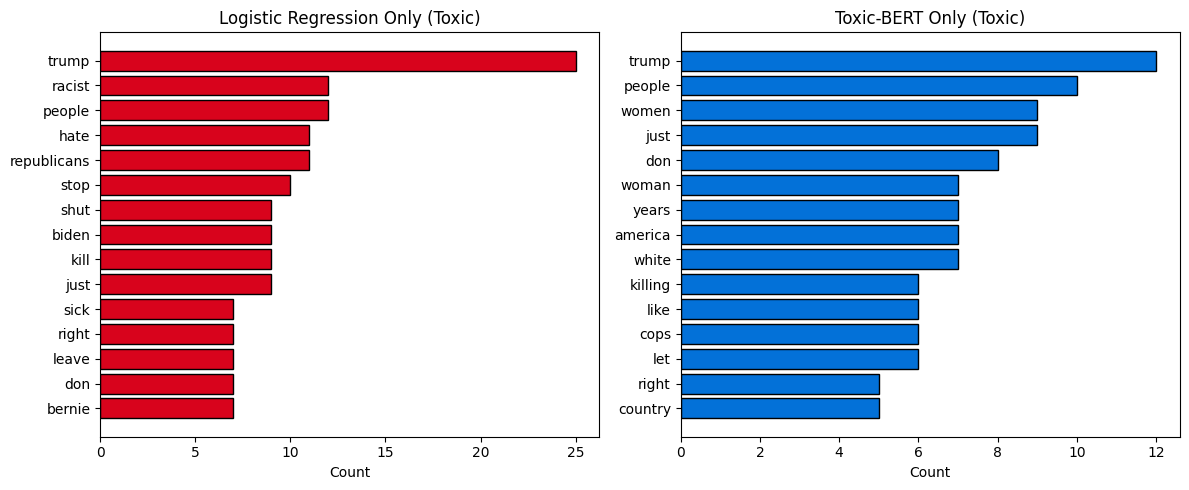

In [107]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# Subsets
df_lr_only = df[(df['logreg_pred'] == 1) & (df['bert_pred'] == 0)]
df_bert_only = df[(df['bert_pred'] == 1) & (df['logreg_pred'] == 0)]

# Function to get top words
def get_top_words(text_series, max_features=15):
    texts = text_series.fillna('').astype(str)
    
    vectorizer = CountVectorizer(
        stop_words='english',
        max_features=max_features,
        token_pattern=r'\b[a-zA-Z]{3,}\b'  # remove very short tokens
    )
    
    X = vectorizer.fit_transform(texts)
    counts = X.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()
    
    df_freq = pd.DataFrame({'word': words, 'count': counts})
    df_freq = df_freq.sort_values('count', ascending=True)  # for horizontal bars
    
    return df_freq

# Get frequencies
freq_lr = get_top_words(df_lr_only['title'])
freq_bert = get_top_words(df_bert_only['title'])

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LR-only
axes[0].barh(freq_lr['word'], freq_lr['count'],
             color='#d8031c', edgecolor='black')
axes[0].set_title('Logistic Regression Only (Toxic)')
axes[0].set_xlabel('Count')

# BERT-only
axes[1].barh(freq_bert['word'], freq_bert['count'],
             color='#0371d8', edgecolor='black')
axes[1].set_title('Toxic-BERT Only (Toxic)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [108]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def get_top_words(text_series, max_features=15):
    texts = text_series.fillna('').astype(str)

    # Custom stopwords (add your own)
    custom_stopwords = [
        'just', 'don', 'like', 'people', 'right', 'let', 'get',
        'one', 'will', 'make', 'even', 'really', 'think'
    ]

    vectorizer = CountVectorizer(
        stop_words='english',
        ngram_range=(1, 2),  # unigrams + bigrams
        max_features=50,     # get more, then filter down
        token_pattern=r'\b[a-zA-Z]{3,}\b'
    )

    X = vectorizer.fit_transform(texts)
    counts = X.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()

    df_freq = pd.DataFrame({'word': words, 'count': counts})

    # Remove custom stopwords and near-generic words
    df_freq = df_freq[~df_freq['word'].isin(custom_stopwords)]

    # Optional: remove words containing generic tokens
    df_freq = df_freq[~df_freq['word'].str.contains(r'\b(just|people|like|right)\b')]

    # Sort and keep top N
    df_freq = df_freq.sort_values('count', ascending=False).head(15)

    # Reverse for horizontal bar plot
    df_freq = df_freq.sort_values('count', ascending=True)

    return df_freq

C:\Users\enora\AppData\Local\Temp\ipykernel_1888\3188921790.py:30: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_freq = df_freq[~df_freq['word'].str.contains(r'\b(just|people|like|right)\b')]
C:\Users\enora\AppData\Local\Temp\ipykernel_1888\3188921790.py:30: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_freq = df_freq[~df_freq['word'].str.contains(r'\b(just|people|like|right)\b')]


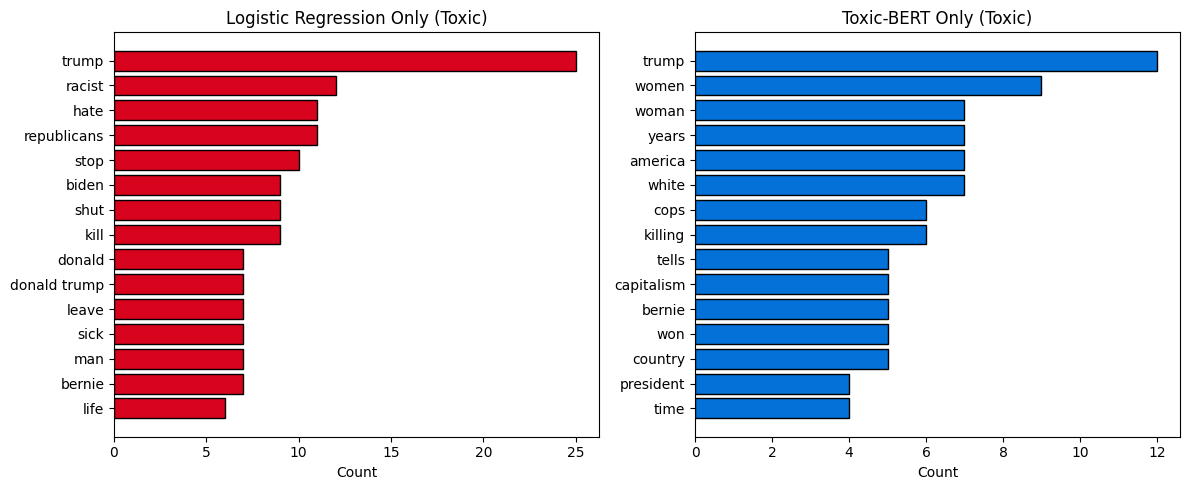

In [110]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# Subsets
df_lr_only = df[(df['logreg_pred'] == 1) & (df['bert_pred'] == 0)]
df_bert_only = df[(df['bert_pred'] == 1) & (df['logreg_pred'] == 0)]

# Get frequencies
freq_lr = get_top_words(df_lr_only['title'])
freq_bert = get_top_words(df_bert_only['title'])

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LR-only
axes[0].barh(freq_lr['word'], freq_lr['count'],
             color='#d8031c', edgecolor='black')
axes[0].set_title('Logistic Regression Only (Toxic)')
axes[0].set_xlabel('Count')

# BERT-only
axes[1].barh(freq_bert['word'], freq_bert['count'],
             color='#0371d8', edgecolor='black')
axes[1].set_title('Toxic-BERT Only (Toxic)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [117]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

def get_top_words(text_series, max_features=15):
    texts = text_series.fillna('').astype(str)

    # Custom stopwords (add your own)
    custom_stopwords = [
        'just', 'don', 'like', 'people', 'right', 'let', 'get',
        'one', 'will', 'make', 'even', 'really', 'think'
    ]

    vectorizer = CountVectorizer(
        stop_words='english',
        ngram_range=(1, 2),  # unigrams + bigrams
        max_features=50,     # get more, then filter down
        token_pattern=r'\b[a-zA-Z]{3,}\b'
    )

    X = vectorizer.fit_transform(texts)
    counts = X.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()

    df_freq = pd.DataFrame({'word': words, 'count': counts})

    # Remove custom stopwords and near-generic words
    df_freq = df_freq[~df_freq['word'].isin(custom_stopwords)]

    # Optional: remove words containing generic tokens
    df_freq = df_freq[~df_freq['word'].str.contains(r'\b(just|people|like|right)\b')]
    df_freq = df_freq[~df_freq['word'].str.contains(r'\b(trump|donald|biden|bernie)\b')]
    
    # Sort and keep top N
    df_freq = df_freq.sort_values('count', ascending=False).head(15)

    # Reverse for horizontal bar plot
    df_freq = df_freq.sort_values('count', ascending=True)

    return df_freq

C:\Users\enora\AppData\Local\Temp\ipykernel_1888\645645176.py:30: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_freq = df_freq[~df_freq['word'].str.contains(r'\b(just|people|like|right)\b')]
C:\Users\enora\AppData\Local\Temp\ipykernel_1888\645645176.py:31: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_freq = df_freq[~df_freq['word'].str.contains(r'\b(trump|donald|biden|bernie)\b')]
C:\Users\enora\AppData\Local\Temp\ipykernel_1888\645645176.py:30: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_freq = df_freq[~df_freq['word'].str.contains(r'\b(just|people|like|right)\b')]
C:\Users\enora\AppData\Local\Temp\ipykernel_1888\645645176.py:31: UserWarning: This pattern is interpreted as a regular expression, and has match gr

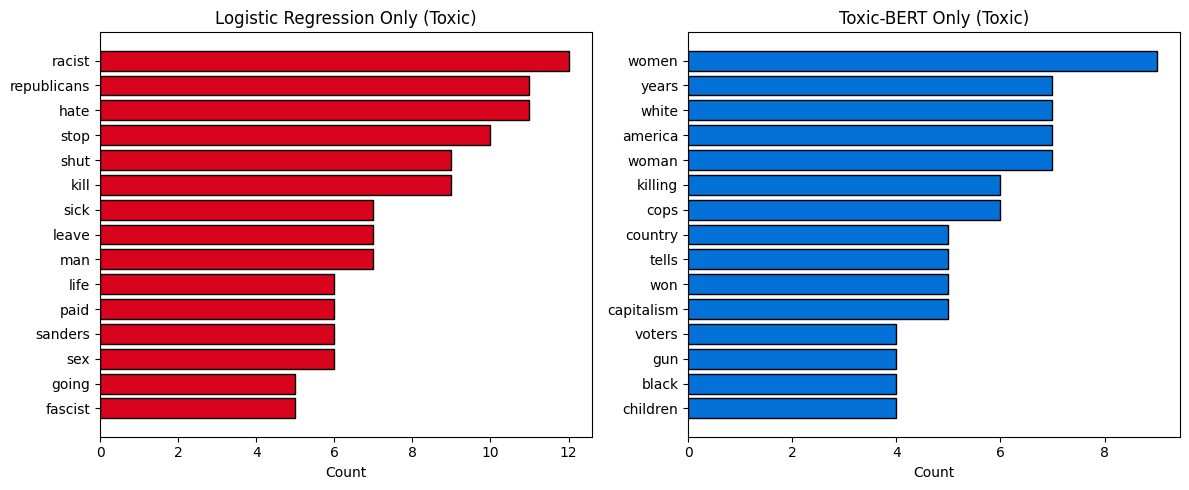

In [118]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt

# Subsets
df_lr_only = df[(df['logreg_pred'] == 1) & (df['bert_pred'] == 0)]
df_bert_only = df[(df['bert_pred'] == 1) & (df['logreg_pred'] == 0)]

# Get frequencies
freq_lr = get_top_words(df_lr_only['title'])
freq_bert = get_top_words(df_bert_only['title'])

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# LR-only
axes[0].barh(freq_lr['word'], freq_lr['count'],
             color='#d8031c', edgecolor='black')
axes[0].set_title('Logistic Regression Only (Toxic)')
axes[0].set_xlabel('Count')

# BERT-only
axes[1].barh(freq_bert['word'], freq_bert['count'],
             color='#0371d8', edgecolor='black')
axes[1].set_title('Toxic-BERT Only (Toxic)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()